# ChEMBL Database
- Database of bioactive drug-like small molecules.
- Contains 2-D structures, calculated properties (logP, Molecular Weight, Lipinski Parameters, etc.) and abstracted bioactivities (binding constants, pharmacology and ADMET data).

- Normalised bioactivities into a uniform set of end-points and units (where possible). 
- Links between a molecular target and a published assay are tagged with a set of varying confidence levels.

In [18]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

In [19]:
# Target search for sars-cov-2
target = new_client.target
target_query = target.search('acetylcholinesterase')
targets = pd.DataFrame.from_dict(target_query)
targets.head()

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Drosophila melanogaster,Acetylcholinesterase,18.0,False,CHEMBL2242744,"[{'accession': 'P07140', 'component_descriptio...",SINGLE PROTEIN,7227
1,[],Homo sapiens,Acetylcholinesterase,16.0,False,CHEMBL220,"[{'accession': 'P22303', 'component_descriptio...",SINGLE PROTEIN,9606
2,[],Torpedo californica,Acetylcholinesterase,16.0,False,CHEMBL4780,"[{'accession': 'P04058', 'component_descriptio...",SINGLE PROTEIN,7787
3,[],Mus musculus,Acetylcholinesterase,16.0,False,CHEMBL3198,"[{'accession': 'P21836', 'component_descriptio...",SINGLE PROTEIN,10090
4,[],Rattus norvegicus,Acetylcholinesterase,16.0,False,CHEMBL3199,"[{'accession': 'P37136', 'component_descriptio...",SINGLE PROTEIN,10116


### Select and retrieve bioactivity data for Human Acetylcholinesterase (fifth entry)
- Assign entry corresponding to the target protein, Human Acetylcholinesterase to the selected_target variable. 
- Retrieve bioactivity data for Human Acetylcholinesterase (CHEMBL220) that are reported as pChEMBL values.

In [20]:
# Select targets corresponding to Human Acetylcholinesterase (ChEMBL Target ID: CHEMBL220)
selected_target = targets.target_chembl_id[1]
print(selected_target)
'''
activity = new_client.activity
results = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")
df = pd.DataFrame.from_dict(results)
df.to_csv('acetylcholinesterase_activity_raw.csv', index=False)
df.head()
'''

CHEMBL220


'\nactivity = new_client.activity\nresults = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")\ndf = pd.DataFrame.from_dict(results)\ndf.to_csv(\'acetylcholinesterase_activity_raw.csv\', index=False)\ndf.head()\n'

### Retrieve Bioactivity data for Human Acetylcholinesterase CHEMBL220 
- Bioactivity data here is reported as pChEMBL values (-log(Molar Concentration))
- Filter results on target and IC50 (compound concentration required to inhibit a biological process by 50%)

In [31]:
query = (
    new_client.activity
    .filter(target_chembl_id=selected_target)
    .filter(standard_type="IC50")
)

df = pd.DataFrame.from_dict(query)

In [34]:
print(df.shape)
df.head(3)

(10079, 47)


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,NaN,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,NaN,None,IC50,uM,UO_0000065,NaN,0.75
1,None,NaN,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,NaN,None,IC50,uM,UO_0000065,NaN,0.1
2,None,NaN,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,None,None,BAO_0000190,...,Homo sapiens,Acetylcholinesterase,9606,NaN,None,IC50,uM,UO_0000065,NaN,50.0


In [36]:
# save raw data to csv
df.to_csv('acetylcholinesterase_activity_01_raw.csv', index=False)

### Remove rows missing data for standard_value or canonical_smiles:

#### SMILES: Simplified Molecular Input Line Entry System
Text-based notation that represents chemical structures as short ASCII character strings - translates complex 3D molecular structures into a 1D string.

- Atoms: Represented by standard atomic symbols (e.g., C, N, O, S). Hydrogen atoms attached to carbons are usually omitted. Atoms requiring special charges, isotopes, or from outside the standard subset of organic elements are enclosed in brackets, e.g., \([Na^+]\) or \([13C]\).
- Bonds: Single bonds are implied by placing atomic symbols together (e.g., CC for ethane). Explicit bonds are denoted with specific characters:= for double bonds (e.g., O=C=O for carbon dioxide)# for triple bonds (e.g., C#N for hydrogen cyanide)
    - "=" for double bonds (e.g., O=C=O for carbon dioxide)
    - "#" for triple bonds (e.g., C#N for hydrogen cyanide)


In [ ]:
df2 = df[df.standard_value.notna()]
df2 = df2[df.canonical_smiles.notna()]

8791


/var/folders/2j/29xrv69167354vjz5qvxylsc0000gn/T/ipykernel_90085/3378098703.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[df.canonical_smiles.notna()]


In [38]:
df2.shape

(8791, 47)

In [41]:
# Get count of items with unique canonical smiles values
print(len(df2.canonical_smiles.unique()))

7175


In [45]:
df2 = df2.drop_duplicates(subset=['canonical_smiles'])
dups = df2.duplicated(subset=['canonical_smiles']).sum()
print(dups)

0


In [47]:
df2["canonical_smiles"].head()

0                CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1
1           O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1
2    CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1
3        O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F
4            CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C
Name: canonical_smiles, dtype: str

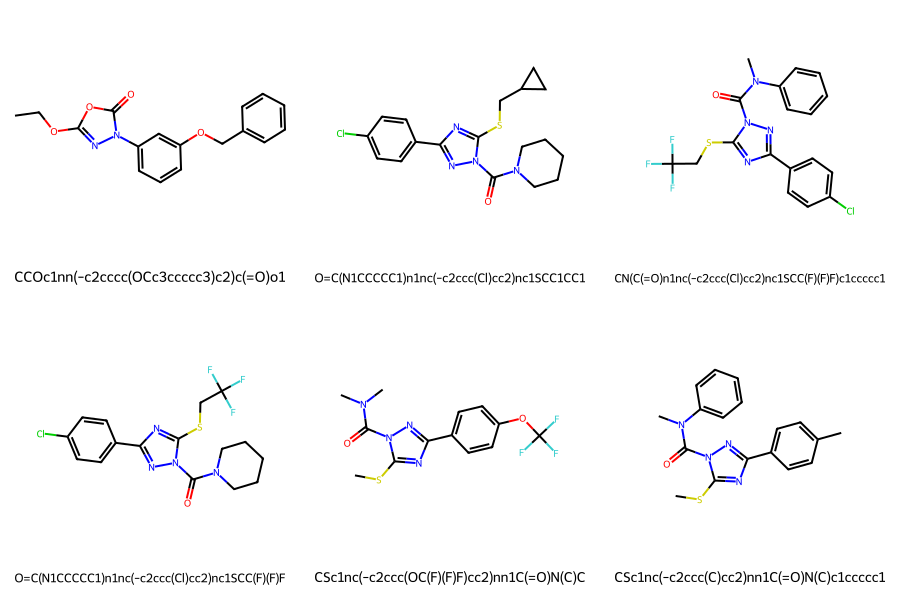

In [51]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw

# Convert the first 5 canonical SMILES to RDKit molecule objects
molecules = [Chem.MolFromSmiles(smiles) for smiles in df2["canonical_smiles"].head(6)]
# Calculate molecular descriptors for the first 5 molecules
#descriptors = [Descriptors.MolWt(mol) for mol in molecules]
labels = [smiles for smiles in df2["canonical_smiles"].head(6)]
# Draw the first 5 molecules with labels
grid_image = Draw.MolsToGridImage(
    molecules, 
    legends=labels, 
    molsPerRow=3, 
    subImgSize=(300, 300)
    )
grid_image

## Pre-process Bioactivity Data
Create a df from molecule_chembl_id, canonical_smiles, standard_value, and bioactivity_class.